# PDF Chunking and RAG Index Exploration

**Purpose:** Prototype and test the full PDF-to-RAG pipeline:
1. PDF parsing with GROBID
2. Section normalization
3. Token-based chunking
4. OpenAI embeddings
5. Qdrant vector indexing

**Prerequisites:**
- Docker services running: `docker compose up -d` (GROBID + Qdrant)
- `OPENAI_API_KEY` set in `.env`
- Package installed: `pip install -e .[dev]`

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import json
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Import project modules
from llm_metadata.pdf_parsing import process_pdf, parse_tei_to_document
from llm_metadata.section_normalize import extract_from_section
from llm_metadata.chunking import (
    chunk_document,
    ChunkingConfig,
    count_tokens
)
from llm_metadata.embedding import (
    embed_chunks,
    EmbeddingConfig
)
from llm_metadata.vector_store import (
    init_collection,
    upsert_chunks,
    search_chunks,
    get_collection_stats,
    VectorStoreConfig
)
from llm_metadata.registry import (
    init_registry,
    upsert_document,
    update_document_status
)

print("✓ Imports successful")

✓ Imports successful


## Test Service Connectivity

In [17]:
# Test GROBID connectivity
import requests
import os

grobid_url = os.getenv("GROBID_URL", "http://localhost:8070")

try:
    response = requests.get(f"{grobid_url}/api/isalive", timeout=5)
    if response.status_code == 200:
        print(f"✓ GROBID is alive at {grobid_url}")
    else:
        print(f"✗ GROBID returned status {response.status_code}")
except Exception as e:
    print(f"✗ GROBID connection failed: {e}")
    print("  Run: docker compose up -d")

✓ GROBID is alive at http://localhost:8070


In [18]:
# Test Qdrant connectivity
from qdrant_client import QdrantClient

qdrant_url = os.getenv("QDRANT_URL", "http://localhost:6333")

try:
    client = QdrantClient(url=qdrant_url)
    collections = client.get_collections()
    print(f"✓ Qdrant is ready at {qdrant_url}")
    print(f"  Collections: {[c.name for c in collections.collections]}")
except Exception as e:
    print(f"✗ Qdrant connection failed: {e}")
    print("  Run: docker compose up -d")

✓ Qdrant is ready at http://localhost:6333
  Collections: ['test_papers_chunks']


## End-to-End Pipeline Demo

Process a single PDF through the full pipeline.

In [3]:
# Select a test PDF
# TODO: Update this path to point to an actual PDF in your data/pdfs/ directory
test_pdf_path = Path("data/pdfs/fuster/10.1002_ece3.1476.pdf")
test_work_id = "TEST_W123"

if not test_pdf_path.exists():
    print(f"⚠ Test PDF not found at {test_pdf_path}")
    print("  Please update the path to an actual PDF")
else:
    print(f"✓ Test PDF found: {test_pdf_path}")
    print(f"  Size: {test_pdf_path.stat().st_size / 1024:.1f} KB")

✓ Test PDF found: data\pdfs\fuster\10.1002_ece3.1476.pdf
  Size: 6300.3 KB


### Stage 1: Parse PDF with GROBID

In [4]:
# Process PDF with GROBID
if test_pdf_path.exists():
    print("Parsing PDF with GROBID...")
    tei_path, doc = process_pdf(test_pdf_path, test_work_id)
    
    print(f"\n✓ Parsing complete")
    print(f"  TEI XML: {tei_path}")
    print(f"  Title: {doc.title}")
    print(f"  Abstract: {doc.abstract[:200] if doc.abstract else 'None'}...")
    print(f"  Language: {doc.language}")
    print(f"  Keywords: {doc.keywords}")
    print(f"  Sections: {len(doc.sections)}")
    print()
    print("Top-level sections:")
    for section in doc.sections:
        section_type = extract_from_section(section.title)
        print(f"  - {section.title} ({section_type.value})")

Parsing PDF with GROBID...

✓ Parsing complete
  TEI XML: C:\Users\beav3503\dev\llm_metadata\artifacts\tei\10.1002_ece3.1476.grobid.tei.xml
  Title: Ecological gradients driving the distribution of four Ericaceae in boreal Quebec, Canada
  Abstract: Understory species play a significant role in forest ecosystem dynamics. As such, species of the Ericaceae family have a major effect on the regeneration of tree species in boreal ecosystems. It is th...
  Language: en
  Keywords: ['Boreal forest', 'Chamaedaphne calyculata', 'ecological drivers', 'Kalmia angustifolia', 'landscape ecology', 'redundancy analysis', 'Rhododendron groenlandicum', 'Vaccinium angustifolium', 'Vaccinium myrtilloides']
  Sections: 23

Top-level sections:
  - Introduction (INTRO)
  - Materials and Methods (METHODS)
  - Study region (OTHER)
  - Data sources (OTHER)
  - Ecological survey dataset (OTHER)
  - Forest survey dataset (OTHER)
  - Ecological district dataset (OTHER)
  - Data analysis (RESULTS)
  - Autecology 

### Stage 2: Chunk Document

In [6]:
# Chunk document
if 'doc' in locals():
    print("Chunking document...")
    
    chunking_config = ChunkingConfig(
        target_tokens=450,
        max_tokens=650,
        overlap_tokens=80
    )
    
    chunks = chunk_document(doc, chunking_config)
    
    print(f"\n✓ Chunking complete")
    print(f"  Total chunks: {len(chunks)}")
    print(f"  Total tokens: {sum(c.token_count for c in chunks):,}")
    print(f"  Avg tokens/chunk: {sum(c.token_count for c in chunks) / len(chunks):.1f}")
    print()
    print("Section distribution:")
    from collections import Counter
    section_counts = Counter(c.section.section_type_normalized.value for c in chunks)
    for section_type, count in section_counts.most_common():
        print(f"  {section_type}: {count} chunks")
    print()
    print("Sample chunk:")
    sample = chunks[0]
    print(f"  ID: {sample.chunk_id}")
    print(f"  Section: {sample.section.section_path}")
    print(f"  Tokens: {sample.token_count}")
    print(f"  Text: {sample.text[:200]}...")

Chunking document...

✓ Chunking complete
  Total chunks: 25
  Total tokens: 8,976
  Avg tokens/chunk: 359.0

Section distribution:
  OTHER: 18 chunks
  DISCUSSION: 3 chunks
  INTRO: 2 chunks
  ABSTRACT: 1 chunks
  CONCLUSION: 1 chunks

Sample chunk:
  ID: TEST_W123_chunk_1
  Section: Abstract
  Tokens: 377
  Text: Understory species play a significant role in forest ecosystem dynamics. As such, species of the Ericaceae family have a major effect on the regeneration of tree species in boreal ecosystems. It is th...


### Stage 3: Generate Embeddings

In [7]:
# Generate embeddings (requires OPENAI_API_KEY)
if 'chunks' in locals():
    print("Generating embeddings...")
    
    embedding_config = EmbeddingConfig(
        model="text-embedding-3-large",
        dimensions=3072,
        batch_size=100
    )
    
    try:
        embeddings, cache = embed_chunks(chunks, embedding_config, use_cache=True)
        
        print(f"\n✓ Embeddings generated")
        print(f"  Vectors: {len(embeddings)}")
        print(f"  Dimensions: {len(embeddings[0])}")
        print(f"  Cache size: {len(cache)} records")
    except Exception as e:
        print(f"\n✗ Embedding failed: {e}")
        print("  Make sure OPENAI_API_KEY is set in .env")

Generating embeddings...
Embedding 25/25 chunks (cache misses)
Updated embedding cache: C:\Users\beav3503\dev\llm_metadata\artifacts\chunks\TEST_W123.embeddings.jsonl

✓ Embeddings generated
  Vectors: 25
  Dimensions: 3072
  Cache size: 25 records


### Stage 4: Index in Qdrant

In [10]:
# Initialize collection
vector_config = VectorStoreConfig(
    collection_name="test_papers_chunks",
    vector_size=3072
)

print("Initializing Qdrant collection...")
init_collection(vector_config, recreate=True)

# Upsert chunks
if 'embeddings' in locals():
    print("\nIndexing chunks...")
    upsert_chunks(chunks, embeddings, vector_config)
    
    # Get stats
    print("\nCollection statistics:")
    stats = get_collection_stats(vector_config)
    for key, value in stats.items():
        print(f"  {key}: {value}")

Initializing Qdrant collection...
Deleting existing collection: test_papers_chunks
Creating collection: test_papers_chunks
Creating payload indexes...
✓ Collection 'test_papers_chunks' initialized

Indexing chunks...
Upserting 25 points to collection 'test_papers_chunks'...
✓ Upserted 25 chunks

Collection statistics:
  collection_name: test_papers_chunks
  points_count: 25
  vectors_count: 25
  indexed_vectors_count: 0
  status: green


### Stage 5: Test Retrieval

In [13]:
# Test search with first chunk's embedding as query
if 'embeddings' in locals():
    print("Testing retrieval...")
    
    query_vector = embeddings[0]
    results = search_chunks(
        query_vector,
        vector_config,
        limit=3,
        exclude_references=True
    )
    
    print(f"\n✓ Found {len(results)} results")
    print()
    for i, result in enumerate(results, 1):
        print(f"Result {i}:")
        print(f"  Score: {result['score']:.4f}")
        print(f"  Section: {result['payload']['section_path']}")
        print(f"  Text: {result['payload']['text'][:150]}...")
        print()

Testing retrieval...

✓ Found 3 results

Result 1:
  Score: 1.0000
  Section: Abstract
  Text: Understory species play a significant role in forest ecosystem dynamics. As such, species of the Ericaceae family have a major effect on the regenerat...

Result 2:
  Score: 0.9059
  Section: Introduction
  Text: Nonetheless, these ericaceous species respond locally to ecological drivers. For example, an assessment of three common ericaceous species conducted i...

Result 3:
  Score: 0.8306
  Section: Discussion
  Text: Our study is in line with previous work grounded in numerical ecology that has defined ecological gradients for large territories, regionalizing veget...



### Stage 6: Semantic Query Search

Test retrieval with a natural language query about datasets.

In [20]:
# Semantic search with natural language query
if 'embeddings' in locals():
    import openai
    
    # Natural language query
    query_text = "Provide a description of the datasets used within the study"
    
    print(f"Query: {query_text}")
    print(f"\nGenerating query embedding...")
    
    # Embed the query using same model as chunks
    response = openai.embeddings.create(
        model=embedding_config.model,
        input=query_text,
        dimensions=embedding_config.dimensions
    )
    query_embedding = response.data[0].embedding
    
    print(f"✓ Query embedded ({len(query_embedding)} dimensions)")
    
    # Search for relevant chunks
    print(f"\nSearching for relevant chunks...")
    results = search_chunks(
        query_embedding,
        vector_config,
        limit=5,
        exclude_references=True
    )
    
    print(f"\n✓ Found {len(results)} results\n")
    print("="*80)
    
    for i, result in enumerate(results, 1):
        print(f"\n[Result {i}] Score: {result['score']:.4f}")
        print(f"Section Title: {result['payload']['section_title']}")
        print(f"Section Type: {result['payload']['section_type']}")
        print(f"Section Path: {result['payload']['section_path']}")
        print(f"\nText:\n{result['payload']['text'][:400]}...")
        print("-"*80)

Query: Provide a description of the datasets used within the study

Generating query embedding...
✓ Query embedded (3072 dimensions)

Searching for relevant chunks...

✓ Found 5 results


[Result 1] Score: 0.4119
Section Title: Ecological survey dataset
Section Type: OTHER
Section Path: Ecological survey dataset

Text:
Data on the abundance of the four ericaceous species were extracted from a governmental ecological survey dataset. The survey was conducted between 1986 and 2000; 15,339 ecological sampling plots were established in our study area (Fig. 2). Saucier et al. (1994) provide a detailed description of the sampling procedure. In summary, sampling plots consisted of circular 400 m 2 plots distributed alon...
--------------------------------------------------------------------------------

[Result 2] Score: 0.4090
Section Title: Ecological district dataset
Section Type: OTHER
Section Path: Ecological district dataset

Text:
Data from the ecological survey dataset and SIFORT were 

### Stage 7: Metadata-Only Filtering

Retrieve chunks by filtering on metadata fields without semantic search.

In [23]:
# Metadata-only filtering examples
from qdrant_client.models import Filter, FieldCondition, MatchValue

if 'embeddings' in locals():
    client = QdrantClient(url=qdrant_url)
    
    # Example 1: Filter by section type (DISCUSSION chunks only)
    print("="*80)
    print("Example 1: Filter by normalized section type (DISCUSSION)")
    print("="*80)
    
    discussion_filter = Filter(
        must=[
            FieldCondition(
                key="section_type",
                match=MatchValue(value="DISCUSSION")
            )
        ]
    )
    
    # Scroll to get all matching points (no semantic search, just filtering)
    discussion_results = client.scroll(
        collection_name=vector_config.collection_name,
        scroll_filter=discussion_filter,
        limit=10
    )
    
    print(f"\nFound {len(discussion_results[0])} DISCUSSION chunks:\n")
    for point in discussion_results[0]:
        print(f"  • {point.payload['section_title']}")
        print(f"    Path: {point.payload['section_path']}")
        print(f"    Tokens: {point.payload['token_count']}")
        print(f"    Text: {point.payload['text'][:100]}...\n")
    
    # Example 2: Filter by raw section title (exact match)
    print("\n" + "="*80)
    print("Example 2: Filter by raw section title (contains 'dataset')")
    print("="*80)
    
    # Note: Qdrant's text matching is case-sensitive by default
    # For partial matching, we need to scroll all and filter in Python
    all_results = client.scroll(
        collection_name=vector_config.collection_name,
        limit=100
    )
    
    dataset_chunks = [
        point for point in all_results[0]
        if 'dataset' in point.payload['section_title'].lower()
    ]
    
    print(f"\nFound {len(dataset_chunks)} chunks with 'dataset' in section title:\n")
    for point in dataset_chunks:
        print(f"  • {point.payload['section_title']}")
        print(f"    Type: {point.payload['section_type']}")
        print(f"    Path: {point.payload['section_path']}")
        print(f"    Text: {point.payload['text'][:120]}...\n")
    
    # Example 3: Combined filters (section type + content flags)
    print("\n" + "="*80)
    print("Example 3: Combined filters (has_figure_mention=True)")
    print("="*80)
    
    figure_filter = Filter(
        must=[
            FieldCondition(
                key="has_figure_mention",
                match=MatchValue(value=True)
            )
        ]
    )
    
    figure_results = client.scroll(
        collection_name=vector_config.collection_name,
        scroll_filter=figure_filter,
        limit=5
    )
    
    print(f"\nFound {len(figure_results[0])} chunks with figure mentions (showing first 5):\n")
    for point in figure_results[0]:
        print(f"  • Section: {point.payload['section_title']} ({point.payload['section_type']})")
        print(f"    Text: {point.payload['text'][:150]}...\n")
    
    print("="*80)
    print("\nMetadata filtering allows you to:")
    print("  - Retrieve chunks without needing a query vector")
    print("  - Filter by section_type, section_title, section_path")
    print("  - Filter by content flags (has_figure, has_table, has_equation)")
    print("  - Combine multiple conditions with AND/OR logic")
    print("  - Great for exploratory analysis and data quality checks")

Example 1: Filter by normalized section type (DISCUSSION)

Found 3 DISCUSSION chunks:

  • Discussion
    Path: Discussion
    Tokens: 548
    Text: Our results support that there is a strong relation between forest types and understory species and ...

  • Discussion
    Path: Discussion
    Tokens: 624
    Text: Classification work conducted at smaller scales has shown that variables related to the physical env...

  • Discussion
    Path: Discussion
    Tokens: 628
    Text: Our study is in line with previous work grounded in numerical ecology that has defined ecological gr...


Example 2: Filter by raw section title (contains 'dataset')

Found 3 chunks with 'dataset' in section title:

  • Forest survey dataset
    Type: OTHER
    Path: Forest survey dataset
    Text: We used geospatial databases developed from forest maps produced at the scale of 1:20,000 from aerial photographs. This ...

  • Ecological survey dataset
    Type: OTHER
    Path: Ecological survey dataset
    Text: 

## Registry Management

In [14]:
# Initialize registry
from llm_metadata.pdf_parsing import compute_pdf_hash

init_registry()

if test_pdf_path.exists():
    # Add document to registry
    pdf_hash = compute_pdf_hash(test_pdf_path)
    
    upsert_document(
        work_id=test_work_id,
        pdf_sha256=pdf_hash,
        source_path=test_pdf_path,
        doi="10.1234/test",
        title="Test Paper" if 'doc' not in locals() else doc.title,
        status="INDEXED",
        parser_version="grobid-0.8.0"
    )
    
    print(f"✓ Document registered in registry")
    print(f"  Work ID: {test_work_id}")
    print(f"  SHA256: {pdf_hash[:16]}...")

✓ Document registered in registry
  Work ID: TEST_W123
  SHA256: 49307879d6175d28...


## Analysis and Metrics

Chunk statistics:
       token_count  section_level
count    25.000000           25.0
mean    359.040000            1.0
std     204.089947            0.0
min       7.000000            1.0
25%     231.000000            1.0
50%     339.000000            1.0
75%     548.000000            1.0
max     649.000000            1.0

Content flags:
  has_equation: 0 (0.0%)
  has_table: 2 (8.0%)
  has_figure: 15 (60.0%)


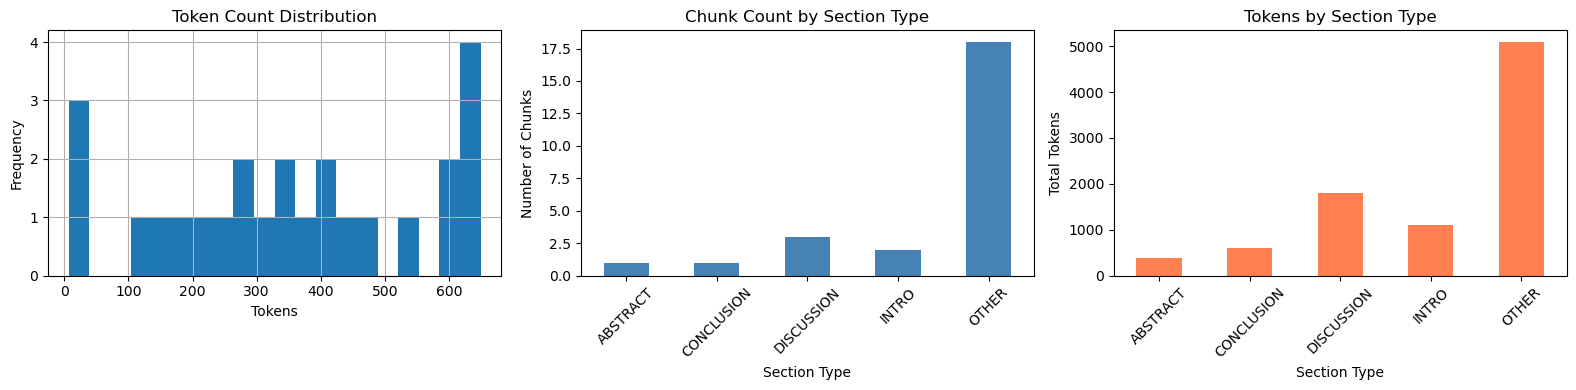

In [19]:
# Analyze chunk statistics
if 'chunks' in locals():
    import pandas as pd
    import matplotlib.pyplot as plt
    
    # Create DataFrame
    df = pd.DataFrame([
        {
            'chunk_id': c.chunk_id,
            'section_type': c.section.section_type_normalized.value,
            'section_level': c.section.section_level,
            'token_count': c.token_count,
            'is_abstract': c.is_abstract,
            'is_references': c.is_references,
            'has_equation': c.has_equation,
            'has_table': c.has_table_mention,
            'has_figure': c.has_figure_mention
        }
        for c in chunks
    ])
    
    print("Chunk statistics:")
    print(df[['token_count', 'section_level']].describe())
    print()
    print("Content flags:")
    for col in ['has_equation', 'has_table', 'has_figure']:
        count = df[col].sum()
        pct = 100 * count / len(df)
        print(f"  {col}: {count} ({pct:.1f}%)")
    
    # Plot visualizations
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Token count distribution
    df['token_count'].hist(bins=20, ax=axes[0])
    axes[0].set_title('Token Count Distribution')
    axes[0].set_xlabel('Tokens')
    axes[0].set_ylabel('Frequency')
    
    # Chunks by section type
    section_counts = df['section_type'].value_counts().sort_index()
    section_counts.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Chunk Count by Section Type')
    axes[1].set_xlabel('Section Type')
    axes[1].set_ylabel('Number of Chunks')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Total tokens by section type
    df.groupby('section_type')['token_count'].sum().plot(kind='bar', ax=axes[2], color='coral')
    axes[2].set_title('Tokens by Section Type')
    axes[2].set_xlabel('Section Type')
    axes[2].set_ylabel('Total Tokens')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Next Steps

1. **Batch Processing**: Process multiple PDFs from `data/pdfs/`
2. **RAG Evaluation**: Compare full-text vs abstract-only feature extraction
3. **Query Testing**: Test different retrieval filters and parameters
4. **Performance**: Measure throughput and cost for Fuster dataset

See `tasks/article-full-text-chunking.md` for full pipeline specification.